### Integrate Supplementary Features

In [ ]:
# integrating features from onehot encoding and gc skew (and/or at/gc content)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np


def calculate_gc_content(sequence):
    """Calculates GC content of a DNA sequence."""
    gc_count = sequence.count('G') + sequence.count('C')
    return gc_count / len(sequence) if len(sequence) > 0 else 0


def calculate_at_gc_skew(sequence):
    """Calculates AT and GC skew of a DNA sequence."""
    a_count, t_count = sequence.count('A'), sequence.count('T')
    g_count, c_count = sequence.count('G'), sequence.count('C')
    at_skew = (a_count - t_count) / (a_count + t_count) if (a_count + t_count) > 0 else 0
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0
    return at_skew, gc_skew


def nucleotide_composition(sequence):
    """Calculates mono, di, and tri-nucleotide composition."""
    composition = {}
    for n in range(1, 4):  # Mono, di, tri-nucleotide
        counts = {sequence[i:i+n]: sequence[i:i+n].count(sequence[i:i+n])
                  for i in range(len(sequence) - n + 1)}
        total = sum(counts.values())
        composition.update({f"{n}-mer_{key}": val / total for key, val in counts.items()})
    return composition

def one_hot_encode(sequence):
    """
    One-hot encodes a DNA sequence.

    Args:
        sequence (str): DNA sequence consisting of 'A', 'T', 'G', 'C'.

    Returns:
        np.ndarray: One-hot encoded matrix of shape (len(sequence), 4).
    """
    # Define a mapping for each nucleotide
    mapping = {'A': [1, 0, 0, 0],
               'T': [0, 1, 0, 0],
               'G': [0, 0, 1, 0],
               'C': [0, 0, 0, 1]}

    # Convert sequence to one-hot encoded matrix
    one_hot_matrix = np.array([mapping.get(nucleotide, [0, 0, 0, 0]) for nucleotide in sequence])
    return one_hot_matrix.flatten()  # Flatten into a 1D vector


def preprocess_dataframe_with_additional_features(df, ngram_range=(6, 6), max_features=5000):
    """
    Processes the dataframe to encode sequences using CountVectorizer for k-mer frequencies
    and adds additional features like GC content, AT/GC skew, and nucleotide composition.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.
        ngram_range (tuple): Range of n-grams to use in encoding.
        max_features (int): Maximum number of features to include in CountVectorizer.

    Returns:
        X (DataFrame): Combined feature matrix.
        y (array): Encoded labels.
        vectorizer (CountVectorizer): Fitted vectorizer for future use.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Label encode the genotypes
    le = LabelEncoder()
    df['genotype_encoded'] = le.fit_transform(df['genotype'])

    # one-hot encoding features
    onehot_features = []
    for sequence in df['seq']:
        onehot_features.append(one_hot_encode(sequence))


    # Pad sequences to a fixed length (assuming max_seq_length is the desired length)
    max_seq_length = 1000
    onehot_padded_features = pad_sequences(onehot_features, maxlen=max_seq_length, padding='post').tolist()

    # Calculate additional features
    additional_features = []
    for sequence in df['seq']:
        # features = {
        #     'gc_content': calculate_gc_content(sequence),
        # }
        features = {}
        # Calculate AT/GC skew
        at_skew, gc_skew = calculate_at_gc_skew(sequence)
        # features['at_skew'] = at_skew
        features['gc_skew'] = gc_skew

        # Add mono, di, tri-nucleotide composition
        # features.update(nucleotide_composition(sequence))
        additional_features.append(features)

    additional_features_df = pd.DataFrame(additional_features).fillna(0)

    # Combine k-mer and additional features
    onehot_features_df = pd.DataFrame(onehot_padded_features)
    combined_features = pd.concat([onehot_features_df, additional_features_df], axis=1)

    y = df['genotype_encoded']
    return combined_features, y, le


def train_model_with_additional_features(df):
    """
    Main function to preprocess data using CountVectorizer and additional features,
    train a Random Forest classifier, and evaluate it.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.

    Returns:
        rf (RandomForestClassifier): Trained Random Forest model.
        vectorizer (CountVectorizer): Fitted vectorizer for future use.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Preprocess data
    X, y, le = preprocess_dataframe_with_additional_features(df)

    # # Split data
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # # Train Random Forest Classifier
    # rf = RandomForestClassifier(n_estimators=100, random_state=42)
    # rf.fit(X_train, y_train)

    # # Evaluate the model
    # y_pred = rf.predict(X_test)
    # print("Classification Report:")
    # print(classification_report(y_test, y_pred, target_names=le.classes_))
    # print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    return le, X, y


# Example Usage:
data = pd.read_csv('data.csv')
data.drop_duplicates(subset='seq',keep='first', inplace=True)
# Assuming 'data' is a DataFrame with columns 'seq' and 'genotype'
label_encoder, X, y = train_model_with_additional_features(data)

In [ ]:
# Do the FCGR then combine the extracted features with the gc skew (and/or other additional features)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np


def calculate_gc_content(sequence):
    """Calculates GC content of a DNA sequence."""
    gc_count = sequence.count('G') + sequence.count('C')
    return gc_count / len(sequence) if len(sequence) > 0 else 0


def calculate_at_gc_skew(sequence):
    """Calculates AT and GC skew of a DNA sequence."""
    a_count, t_count = sequence.count('A'), sequence.count('T')
    g_count, c_count = sequence.count('G'), sequence.count('C')
    at_skew = (a_count - t_count) / (a_count + t_count) if (a_count + t_count) > 0 else 0
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0
    return at_skew, gc_skew


def generate_fcgr(sequence, k=5, grid_size=32):
    """
    Generate a Frequency Chaos Game Representation (FCGR) grid from a DNA sequence.

    Parameters:
        sequence (str): DNA sequence (A, T, C, G).
        k (int): Length of k-mers.
        grid_size (int): Resolution of the FCGR grid (e.g., 32x32 for k=5).

    Returns:
        np.array: FCGR grid of size grid_size x grid_size.
    """
    # Initialize an empty grid
    fcgr = np.zeros((grid_size, grid_size))

    # Scale factor for mapping coordinates
    scale = grid_size / (2 ** k)

    # Create mapping from nucleotide pairs to 2D coordinates
    mapping = {'A': 0, 'T': 1, 'C': 2, 'G': 3}

    # Iterate over k-mers in the sequence
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i + k]

        # Calculate x and y positions based on k-mer
        x, y = 0, 0
        valid_kmer = True
        for j, nucleotide in enumerate(kmer):
            if nucleotide not in mapping:
                valid_kmer = False
                break
            # Update x and y based on nucleotide position
            factor = 2 ** (k - j - 1)
            x += mapping[nucleotide] % 2 * factor
            y += mapping[nucleotide] // 2 * factor

        if valid_kmer:
            # Map x, y to grid and increment the corresponding cell
            grid_x = int(x * scale)
            grid_y = int(y * scale)
            fcgr[grid_y, grid_x] += 1  # Increment the frequency

    return fcgr

def extract_frequencies(fcgr, sub_grid_size=32):
    """
    Divide the FCGR into sub-regions and calculate k-mer frequencies.

    Parameters:
        fcgr (np.array): FCGR grid (e.g., 32x32).
        sub_grid_size (int): Size of sub-grid (e.g., 8x8).

    Returns:
        np.array: Flattened array of frequencies from all sub-regions.
    """
    # Calculate the size of each sub-grid cell
    cell_size = fcgr.shape[0] // sub_grid_size
    frequencies = []

    # Iterate over the sub-grid
    for row in range(sub_grid_size):
        for col in range(sub_grid_size):
            # Extract the sub-region
            sub_region = fcgr[
                row * cell_size:(row + 1) * cell_size,
                col * cell_size:(col + 1) * cell_size
            ]
            # Calculate the frequency as the sum of pixel intensities
            freq = np.sum(sub_region)
            frequencies.append(freq)

    return np.array(frequencies)


def preprocess_dataframe_with_fcgr_encoding(df, k=5,grid_size=32,sub_grid_size=32):
    """
    Processes the dataframe to encode sequences using FCGR and adds additional features.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.
        resolution (int): Resolution for FCGR encoding.

    Returns:
        X (DataFrame): Combined feature matrix.
        y (array): Encoded labels.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Label encode the genotypes
    le = LabelEncoder()
    df['genotype_encoded'] = le.fit_transform(df['genotype'])

    # Calculate FCGR features
    fcgr_features = []
    for _, row in df.iterrows():
        sequence = row['seq']
        # label = row['genotype']

        # Generate FCGR for the sequence
        fcgr = generate_fcgr(sequence, k, grid_size)

        # Extract frequencies from the FCGR
        frequencies = extract_frequencies(fcgr, sub_grid_size)
        fcgr_features.append(frequencies)

    # Calculate additional features
    additional_features = []
    for sequence in df['seq']:
        # features = {}
        features = {
            'gc_content': calculate_gc_content(sequence),
        }
        # Calculate AT/GC skew
        # at_skew, gc_skew = calculate_at_gc_skew(sequence)
        # features['at_skew'] = at_skew
        # features['gc_skew'] = gc_skew

        additional_features.append(features)

    additional_features_df = pd.DataFrame(additional_features).fillna(0)

    # Combine FCGR and additional features
    # fcgr_features_df = pd.DataFrame(fcgr_features, columns=[f"fcgr_{i}" for i in range(fcgr_features.shape[1])])
    fcgr_features_df = pd.DataFrame(fcgr_features)
    combined_features = pd.concat([fcgr_features_df, additional_features_df], axis=1)

    y = df['genotype_encoded']
    return combined_features, y, le


def train_model_with_additional_features(df, resolution=5):
    """
    Main function to preprocess data using FCGR encoding and additional features,
    train a Random Forest classifier, and evaluate it.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.
        resolution (int): Resolution for FCGR encoding.

    Returns:
        rf (RandomForestClassifier): Trained Random Forest model.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Preprocess data
    X, y, le = preprocess_dataframe_with_fcgr_encoding(df,k=5)

    # # Split data
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # # Train Random Forest Classifier
    # rf = RandomForestClassifier(n_estimators=100, random_state=42)
    # rf.fit(X_train, y_train)

    # # Evaluate the model
    # y_pred = rf.predict(X_test)
    # print("Classification Report:")
    # print(classification_report(y_test, y_pred, target_names=le.classes_))
    # print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    return le, X, y


# Example Usage:
# Assuming 'data' is a DataFrame with columns 'seq' and 'genotype'
label_encoder, X, y = train_model_with_additional_features(data)

In [ ]:
# integrating features from kmer encoding and gc skew (and/or at/gc content)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np


def calculate_gc_content(sequence):
    """Calculates GC content of a DNA sequence."""
    gc_count = sequence.count('G') + sequence.count('C')
    return gc_count / len(sequence) if len(sequence) > 0 else 0


def calculate_at_gc_skew(sequence):
    """Calculates AT and GC skew of a DNA sequence."""
    a_count, t_count = sequence.count('A'), sequence.count('T')
    g_count, c_count = sequence.count('G'), sequence.count('C')
    at_skew = (a_count - t_count) / (a_count + t_count) if (a_count + t_count) > 0 else 0
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0
    return at_skew, gc_skew


def nucleotide_composition(sequence):
    """Calculates mono, di, and tri-nucleotide composition."""
    composition = {}
    for n in range(1, 4):  # Mono, di, tri-nucleotide
        counts = {sequence[i:i+n]: sequence[i:i+n].count(sequence[i:i+n])
                  for i in range(len(sequence) - n + 1)}
        total = sum(counts.values())
        composition.update({f"{n}-mer_{key}": val / total for key, val in counts.items()})
    return composition


def preprocess_dataframe_with_additional_features(df, ngram_range=(5, 5), max_features=1000):
    """
    Processes the dataframe to encode sequences using CountVectorizer for k-mer frequencies
    and adds additional features like GC content, AT/GC skew, and nucleotide composition.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.
        ngram_range (tuple): Range of n-grams to use in encoding.
        max_features (int): Maximum number of features to include in CountVectorizer.

    Returns:
        X (DataFrame): Combined feature matrix.
        y (array): Encoded labels.
        vectorizer (CountVectorizer): Fitted vectorizer for future use.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Label encode the genotypes
    le = LabelEncoder()
    df['genotype_encoded'] = le.fit_transform(df['genotype'])

    # Use CountVectorizer for k-mer encoding
    vectorizer = CountVectorizer(analyzer='char', ngram_range=ngram_range, max_features=max_features)
    kmer_features = vectorizer.fit_transform(df['seq']).toarray()
    kmer_feature_names = vectorizer.get_feature_names_out()

    # Calculate additional features
    additional_features = []
    for sequence in df['seq']:
        # features = {
        #     'gc_content': calculate_gc_content(sequence),
        # }
        features = {}
        # Calculate AT/GC skew
        at_skew, gc_skew = calculate_at_gc_skew(sequence)
        # features['at_skew'] = at_skew
        features['gc_skew'] = gc_skew

        # Add mono, di, tri-nucleotide composition
        # features.update(nucleotide_composition(sequence))
        additional_features.append(features)

    additional_features_df = pd.DataFrame(additional_features).fillna(0)

    # Combine k-mer and additional features
    kmer_features_df = pd.DataFrame(kmer_features, columns=kmer_feature_names)
    combined_features = pd.concat([kmer_features_df, additional_features_df], axis=1)

    y = df['genotype_encoded']
    return combined_features, y, vectorizer, le


def train_model_with_additional_features(df):
    """
    Main function to preprocess data using CountVectorizer and additional features,
    train a Random Forest classifier, and evaluate it.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.

    Returns:
        rf (RandomForestClassifier): Trained Random Forest model.
        vectorizer (CountVectorizer): Fitted vectorizer for future use.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Preprocess data
    X, y, vectorizer, le = preprocess_dataframe_with_additional_features(df)

    # # Split data
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # # Train Random Forest Classifier
    # rf = RandomForestClassifier(n_estimators=100, random_state=42)
    # rf.fit(X_train, y_train)

    # # Evaluate the model
    # y_pred = rf.predict(X_test)
    # print("Classification Report:")
    # print(classification_report(y_test, y_pred, target_names=le.classes_))
    # print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    return vectorizer, le, X, y


data = pd.read_csv('data.csv')
data.drop_duplicates(subset='seq',keep='first', inplace=True)
vectorizer, label_encoder, X, y = train_model_with_additional_features(data)

In [ ]:
# integrating features from label encoding and gc skew (and/or at/gc content)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np


def calculate_gc_content(sequence):
    """Calculates GC content of a DNA sequence."""
    gc_count = sequence.count('G') + sequence.count('C')
    return gc_count / len(sequence) if len(sequence) > 0 else 0


def calculate_at_gc_skew(sequence):
    """Calculates AT and GC skew of a DNA sequence."""
    a_count, t_count = sequence.count('A'), sequence.count('T')
    g_count, c_count = sequence.count('G'), sequence.count('C')
    at_skew = (a_count - t_count) / (a_count + t_count) if (a_count + t_count) > 0 else 0
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0
    return at_skew, gc_skew


def nucleotide_composition(sequence):
    """Calculates mono, di, and tri-nucleotide composition."""
    composition = {}
    for n in range(1, 4):  # Mono, di, tri-nucleotide
        counts = {sequence[i:i+n]: sequence[i:i+n].count(sequence[i:i+n])
                  for i in range(len(sequence) - n + 1)}
        total = sum(counts.values())
        composition.update({f"{n}-mer_{key}": val / total for key, val in counts.items()})
    return composition

def label_encode_dna_sequence(sequence):
    """Label encodes a DNA sequence using integer mapping.

    Args:
        sequence (str): DNA sequence consisting of 'A', 'T', 'G', 'C'.

    Returns:
        list: Label encoded sequence as list of integers.
    """
    encoded_sequence = []
    mapping = {'A': 1, 'T': 4, 'C': 2, 'G': 3}
    for base in sequence:
        encoded_sequence.append(mapping.get(base, 0))  # Default to 0 for unknown bases
    return encoded_sequence


def preprocess_dataframe_with_additional_features(df, ngram_range=(5, 5), max_features=1000):
    """
    Processes the dataframe to encode sequences using label encoding
    and adds additional features like GC content, AT/GC skew, and nucleotide composition.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.
        ngram_range (tuple): Range of n-grams to use in encoding.
        max_features (int): Maximum number of features to include in CountVectorizer.

    Returns:
        X (DataFrame): Combined feature matrix.
        y (array): Encoded labels.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Label encode the genotypes
    le = LabelEncoder()
    df['genotype_encoded'] = le.fit_transform(df['genotype'])

    # Label encode the DNA sequences
    df['encoded_seq'] = df['seq'].apply(label_encode_dna_sequence)

    # Pad sequences to a fixed length
    max_seq_length = 1000
    padded_sequences = pad_sequences(df['encoded_seq'], maxlen=max_seq_length, padding='post')
    label_encoded_features = pd.DataFrame(padded_sequences)

    # Calculate additional features
    additional_features = []
    for sequence in df['seq']:
        # features = {
        #     'gc_content': calculate_gc_content(sequence),
        # }
        features = {}
        # Calculate AT/GC skew
        at_skew, gc_skew = calculate_at_gc_skew(sequence)
        # features['at_skew'] = at_skew
        features['gc_skew'] = gc_skew

        # Add mono, di, tri-nucleotide composition
        # features.update(nucleotide_composition(sequence))
        additional_features.append(features)

    additional_features_df = pd.DataFrame(additional_features).fillna(0)

    # Combine label encoded sequences and additional features
    combined_features = pd.concat([label_encoded_features, additional_features_df], axis=1)

    y = df['genotype_encoded']
    return combined_features, y, le


def train_model_with_additional_features(df):
    """
    Main function to preprocess data using label encoding and additional features,
    train a Random Forest classifier, and evaluate it.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.

    Returns:
        le (LabelEncoder): Fitted label encoder for future use.
        X (DataFrame): Feature matrix.
        y (array): Encoded labels.
    """
    # Preprocess data
    X, y, le = preprocess_dataframe_with_additional_features(df)

    return le, X, y


# Example Usage:
data = pd.read_csv('data.csv')
data.drop_duplicates(subset='seq', keep='first', inplace=True)
# Assuming 'data' is a DataFrame with columns 'seq' and 'genotype'
label_encoder, X, y = train_model_with_additional_features(data)

### Label Encoding

In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Function to encode DNA sequence
def encode_dna_sequence(sequence):
    encoded_sequence = []
    # mapping = {'A': 1, 'T': 0.5, 'C': 0.25, 'G': 0.75, 'N': 0}
    mapping = {'A': 1, 'T': 4, 'C': 2, 'G': 3}
    for base in sequence:
        encoded_sequence.append(mapping.get(base, 0))  # Default to 0 for unknown bases
    return encoded_sequence

# Read data from dataframe
# Assuming df is the dataframe with 'seq' and 'genotype' columns
# Example:
# df = pd.read_csv('data.csv').sample(3000)
data = pd.read_csv('data.csv')
data = data.drop_duplicates(subset=['seq'], keep='first')
df = data.copy()
# Encode the DNA sequences
df['encoded_seq'] = df['seq'].apply(encode_dna_sequence)

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

max_seq_length = 1000

# Pad sequences to a fixed length (assuming max_seq_length is the desired length)
#max_seq_length = 10  # Example max sequence length

df['padded_seq'] = pad_sequences(df['encoded_seq'], maxlen=max_seq_length, padding='post').tolist()

# Split the data into training and testing sets
X = np.array(df['padded_seq'].tolist())
y = np.array(df['genotype'])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data['genotype'])

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier


# X = processed_df.drop('genotype', axis=1).values
# y = processed_df['genotype'].values

# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

#
# y_encoded = label_encoder.fit_transform(processed_df['genotype'])

# Step 1: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, stratify=y, random_state=42
)


# Step 2: Define pipeline
pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy='auto', random_state=42)),
    # ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
    ('clf', xgb.XGBClassifier(n_estimators=300,random_state=42,n_jobs=-1))
    # ('KNN', KNeighborsClassifier(n_neighbors=5))
])

# Step 3: Cross-validation on training set only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"CV Std Dev: {cv_scores.std():.4f}")

# Step 4: Final evaluation on hold-out test set
pipeline.fit(X_train, y_train)
test_score = pipeline.score(X_test, y_test)
print(f"Hold-Out Test Set Accuracy: {test_score:.4f}")

Cross-Validation Accuracy Scores: [0.95099452 0.94724705 0.94667051 0.94811185 0.95156408]
Mean CV Accuracy: 0.9489
CV Std Dev: 0.0020
Hold-Out Test Set Accuracy: 0.9595


In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
from imblearn.over_sampling import SMOTE
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.utils import to_categorical

# X = data.drop('genotype', axis=1).values
# y = data['genotype'].values

# y_encoded = LabelEncoder().fit_transform(y)

# Assume X and y are numpy arrays
# Step 1: Train-test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# One-hot encode y values
num_classes = len(np.unique(y))
y_train_encoded = to_categorical(y_train_full, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)

# Step 2: Cross-validation on the training set
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_index, val_index in kf.split(X_train_full, y_train_full):
    X_train, X_val = X_train_full[train_index], X_train_full[val_index]
    y_train, y_val = y_train_encoded[train_index], y_train_encoded[val_index]

    # Apply SMOTE to training data only
    # smote = SMOTE(random_state=42)
    # X_train, y_train = smote.fit_resample(X_train, y_train)

    model = Sequential()
    model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=10,
        verbose=1,
        validation_data=(X_val, y_val)
    )

    val_predictions = model.predict(X_val)
    val_predictions = np.argmax(val_predictions, axis=1)
    y_val_classes = np.argmax(y_val, axis=1)

    accuracy = accuracy_score(y_val_classes, val_predictions)
    cv_scores.append(accuracy)

print(f"\nCross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"CV Std Dev: {np.std(cv_scores):.4f}")

# Step 3: Final evaluation on hold-out test set
final_model = Sequential()
final_model.add(Dense(256, activation='relu', input_shape=(X_train_full.shape[1],)))
final_model.add(Dense(num_classes, activation='softmax'))

final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
final_model.fit(X_train_full, y_train_encoded, epochs=10, batch_size=32, verbose=1)

test_predictions = final_model.predict(X_test)
test_predictions = np.argmax(test_predictions, axis=1)
y_test_classes = np.argmax(y_test_encoded, axis=1)

test_accuracy = accuracy_score(y_test_classes, test_predictions)
print(f"Hold-Out Test Set Accuracy: {test_accuracy:.4f}")

### FCGR

In [ ]:
import numpy as np
import pandas as pd

def generate_fcgr(sequence, k=5, grid_size=32):
    """
    Generate a Frequency Chaos Game Representation (FCGR) grid from a DNA sequence.

    Parameters:
        sequence (str): DNA sequence (A, T, C, G).
        k (int): Length of k-mers.
        grid_size (int): Resolution of the FCGR grid (e.g., 32x32 for k=5).

    Returns:
        np.array: FCGR grid of size grid_size x grid_size.
    """
    # Initialize an empty grid
    fcgr = np.zeros((grid_size, grid_size))

    # Scale factor for mapping coordinates
    scale = grid_size / (2 ** k)

    # Create mapping from nucleotide pairs to 2D coordinates
    mapping = {'A': 0, 'T': 1, 'C': 2, 'G': 3}

    # Iterate over k-mers in the sequence
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i + k]

        # Calculate x and y positions based on k-mer
        x, y = 0, 0
        valid_kmer = True
        for j, nucleotide in enumerate(kmer):
            if nucleotide not in mapping:
                valid_kmer = False
                break
            # Update x and y based on nucleotide position
            factor = 2 ** (k - j - 1)
            x += mapping[nucleotide] % 2 * factor
            y += mapping[nucleotide] // 2 * factor

        if valid_kmer:
            # Map x, y to grid and increment the corresponding cell
            grid_x = int(x * scale)
            grid_y = int(y * scale)
            fcgr[grid_y, grid_x] += 1  # Increment the frequency

    return fcgr

def extract_frequencies(fcgr, sub_grid_size=8):
    """
    Divide the FCGR into sub-regions and calculate k-mer frequencies.

    Parameters:
        fcgr (np.array): FCGR grid (e.g., 32x32).
        sub_grid_size (int): Size of sub-grid (e.g., 8x8).

    Returns:
        np.array: Flattened array of frequencies from all sub-regions.
    """
    # Calculate the size of each sub-grid cell
    cell_size = fcgr.shape[0] // sub_grid_size
    frequencies = []

    # Iterate over the sub-grid
    for row in range(sub_grid_size):
        for col in range(sub_grid_size):
            # Extract the sub-region
            sub_region = fcgr[
                row * cell_size:(row + 1) * cell_size,
                col * cell_size:(col + 1) * cell_size
            ]
            # Calculate the frequency as the sum of pixel intensities
            freq = np.sum(sub_region)
            frequencies.append(freq)

    return np.array(frequencies)

def process_sequences(df, k=5, grid_size=32, sub_grid_size=32):
    """
    Process sequences in a DataFrame to generate FCGRs and extract frequencies.

    Parameters:
        df (pd.DataFrame): DataFrame with 'seq' (sequences) and 'label' columns.
        k (int): Length of k-mers.
        grid_size (int): Resolution of the FCGR grid (e.g., 32x32).
        sub_grid_size (int): Size of sub-grid for frequency extraction (e.g., 8x8).

    Returns:
        pd.DataFrame: DataFrame of extracted frequencies with corresponding labels.
    """
    data = []
    labels = []

    for _, row in df.iterrows():
        sequence = row['seq']
        label = row['genotype']

        # Generate FCGR for the sequence
        fcgr = generate_fcgr(sequence, k, grid_size)

        # Extract frequencies from the FCGR
        frequencies = extract_frequencies(fcgr, sub_grid_size)

        # Append data and label
        data.append(frequencies)
        labels.append(label)


    # Convert to DataFrame
    feature_df = pd.DataFrame(data)
    feature_df['genotype'] = labels
    return feature_df

data = pd.read_csv('data.csv')
data.drop_duplicates(subset='seq',keep='first', inplace=True)

# Process the sequences to extract k-mer frequencies
processed_df = process_sequences(data, k=5, grid_size=32, sub_grid_size=32)
print(processed_df.head())

     0    1    2    3    4    5    6    7    8    9  ...  1015  1016  1017  \
0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   2.0   2.0   0.0   
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0   1.0   0.0   
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0   0.0   0.0   
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0   0.0   0.0   
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0   0.0   0.0   

   1018  1019  1020  1021  1022  1023  genotype  
0   1.0   1.0   1.0   2.0   2.0   2.0        1a  
1   1.0   0.0   0.0   2.0   2.0   0.0        1a  
2   1.0   0.0   0.0   2.0   2.0   4.0        1a  
3   1.0   0.0   0.0   1.0   2.0   4.0        1a  
4   1.0   0.0   0.0   1.0   2.0   4.0        1a  

[5 rows x 1025 columns]


In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier


# X = processed_df.drop('genotype', axis=1).values
# y = processed_df['genotype'].values

# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

#
# y_encoded = label_encoder.fit_transform(processed_df['genotype'])

# Step 1: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, stratify=y, random_state=42
)


# Step 2: Define pipeline
pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy='auto', random_state=42)),
    # ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
    ('clf', xgb.XGBClassifier(n_estimators=300,random_state=42,n_jobs=-1))
    # ('KNN', KNeighborsClassifier(n_neighbors=5))
])

# Step 3: Cross-validation on training set only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"CV Std Dev: {cv_scores.std():.4f}")

# Step 4: Final evaluation on hold-out test set
pipeline.fit(X_train, y_train)
test_score = pipeline.score(X_test, y_test)
print(f"Hold-Out Test Set Accuracy: {test_score:.4f}")

Cross-Validation Accuracy Scores: [0.95099452 0.94724705 0.94667051 0.94811185 0.95156408]
Mean CV Accuracy: 0.9489
CV Std Dev: 0.0020
Hold-Out Test Set Accuracy: 0.9595


In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
from imblearn.over_sampling import SMOTE
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.utils import to_categorical

# X = data.drop('genotype', axis=1).values
# y = data['genotype'].values

# y_encoded = LabelEncoder().fit_transform(y)

# Assume X and y are numpy arrays
# Step 1: Train-test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# One-hot encode y values
num_classes = len(np.unique(y))
y_train_encoded = to_categorical(y_train_full, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)

# Step 2: Cross-validation on the training set
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_index, val_index in kf.split(X_train_full, y_train_full):
    X_train, X_val = X_train_full[train_index], X_train_full[val_index]
    y_train, y_val = y_train_encoded[train_index], y_train_encoded[val_index]

    # Apply SMOTE to training data only
    # smote = SMOTE(random_state=42)
    # X_train, y_train = smote.fit_resample(X_train, y_train)

    model = Sequential()
    model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=10,
        verbose=1,
        validation_data=(X_val, y_val)
    )

    val_predictions = model.predict(X_val)
    val_predictions = np.argmax(val_predictions, axis=1)
    y_val_classes = np.argmax(y_val, axis=1)

    accuracy = accuracy_score(y_val_classes, val_predictions)
    cv_scores.append(accuracy)

print(f"\nCross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"CV Std Dev: {np.std(cv_scores):.4f}")

# Step 3: Final evaluation on hold-out test set
final_model = Sequential()
final_model.add(Dense(256, activation='relu', input_shape=(X_train_full.shape[1],)))
final_model.add(Dense(num_classes, activation='softmax'))

final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
final_model.fit(X_train_full, y_train_encoded, epochs=10, batch_size=32, verbose=1)

test_predictions = final_model.predict(X_test)
test_predictions = np.argmax(test_predictions, axis=1)
y_test_classes = np.argmax(y_test_encoded, axis=1)

test_accuracy = accuracy_score(y_test_classes, test_predictions)
print(f"Hold-Out Test Set Accuracy: {test_accuracy:.4f}")

### Onehot encoding

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

def one_hot_encode(sequence):
    """
    One-hot encodes a DNA sequence.

    Args:
        sequence (str): DNA sequence consisting of 'A', 'T', 'G', 'C'.

    Returns:
        np.ndarray: One-hot encoded matrix of shape (len(sequence), 4).
    """
    # Define a mapping for each nucleotide
    mapping = {'A': [1, 0, 0, 0],
               'T': [0, 1, 0, 0],
               'G': [0, 0, 1, 0],
               'C': [0, 0, 0, 1]}

    # Convert sequence to one-hot encoded matrix
    one_hot_matrix = np.array([mapping.get(nucleotide, [0, 0, 0, 0]) for nucleotide in sequence])
    return one_hot_matrix.flatten()  # Flatten into a 1D vector

data = pd.read_csv('data.csv')
data.drop_duplicates(subset='seq',keep='first', inplace=True)
data['encoded_seq'] = data['seq'].apply(one_hot_encode)

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_seq_length = 1000

# Pad sequences to a fixed length (assuming max_seq_length is the desired length)
#max_seq_length = 10

data['padded_seq'] = pad_sequences(data['encoded_seq'], maxlen=max_seq_length, padding='post').tolist()

# Split the data into training and testing sets
X = np.array(data['padded_seq'].tolist())
y = np.array(data['genotype'])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data['genotype'])

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier


# X = processed_df.drop('genotype', axis=1).values
# y = processed_df['genotype'].values

# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

#
# y_encoded = label_encoder.fit_transform(processed_df['genotype'])

# Step 1: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, stratify=y, random_state=42
)


# Step 2: Define pipeline
pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy='auto', random_state=42)),
    # ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
    ('clf', xgb.XGBClassifier(n_estimators=300,random_state=42,n_jobs=-1))
    # ('KNN', KNeighborsClassifier(n_neighbors=5))
])

# Step 3: Cross-validation on training set only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"CV Std Dev: {cv_scores.std():.4f}")

# Step 4: Final evaluation on hold-out test set
pipeline.fit(X_train, y_train)
test_score = pipeline.score(X_test, y_test)
print(f"Hold-Out Test Set Accuracy: {test_score:.4f}")

Cross-Validation Accuracy Scores: [0.95099452 0.94724705 0.94667051 0.94811185 0.95156408]
Mean CV Accuracy: 0.9489
CV Std Dev: 0.0020
Hold-Out Test Set Accuracy: 0.9595


In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
from imblearn.over_sampling import SMOTE
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.utils import to_categorical

# X = data.drop('genotype', axis=1).values
# y = data['genotype'].values

# y_encoded = LabelEncoder().fit_transform(y)

# Assume X and y are numpy arrays
# Step 1: Train-test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# One-hot encode y values
num_classes = len(np.unique(y))
y_train_encoded = to_categorical(y_train_full, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)

# Step 2: Cross-validation on the training set
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_index, val_index in kf.split(X_train_full, y_train_full):
    X_train, X_val = X_train_full[train_index], X_train_full[val_index]
    y_train, y_val = y_train_encoded[train_index], y_train_encoded[val_index]

    # Apply SMOTE to training data only
    # smote = SMOTE(random_state=42)
    # X_train, y_train = smote.fit_resample(X_train, y_train)

    model = Sequential()
    model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=10,
        verbose=1,
        validation_data=(X_val, y_val)
    )

    val_predictions = model.predict(X_val)
    val_predictions = np.argmax(val_predictions, axis=1)
    y_val_classes = np.argmax(y_val, axis=1)

    accuracy = accuracy_score(y_val_classes, val_predictions)
    cv_scores.append(accuracy)

print(f"\nCross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"CV Std Dev: {np.std(cv_scores):.4f}")

# Step 3: Final evaluation on hold-out test set
final_model = Sequential()
final_model.add(Dense(256, activation='relu', input_shape=(X_train_full.shape[1],)))
final_model.add(Dense(num_classes, activation='softmax'))

final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
final_model.fit(X_train_full, y_train_encoded, epochs=10, batch_size=32, verbose=1)

test_predictions = final_model.predict(X_test)
test_predictions = np.argmax(test_predictions, axis=1)
y_test_classes = np.argmax(y_test_encoded, axis=1)

test_accuracy = accuracy_score(y_test_classes, test_predictions)
print(f"Hold-Out Test Set Accuracy: {test_accuracy:.4f}")

### K-mer encoding

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd


# Assuming your dataset is in a numpy array 'data' of shape (3000, 5000)
# Normalize data if needed
data = pd.read_csv('data.csv')
data.drop_duplicates(subset='seq',keep='first', inplace=True)

y = data['genotype']
y = LabelEncoder().fit_transform(y)


from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
ngram_range = (3, 3)  # Change this for different n-grams

vectorizer = CountVectorizer(analyzer='char', ngram_range=ngram_range,max_features=5000) # select top 5k frequent features
X = vectorizer.fit_transform(data['seq']).toarray()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier


# X = processed_df.drop('genotype', axis=1).values
# y = processed_df['genotype'].values

# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

#
# y_encoded = label_encoder.fit_transform(processed_df['genotype'])

# Step 1: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, stratify=y, random_state=42
)


# Step 2: Define pipeline
pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy='auto', random_state=42)),
    # ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
    ('clf', xgb.XGBClassifier(n_estimators=300,random_state=42,n_jobs=-1))
    # ('KNN', KNeighborsClassifier(n_neighbors=5))
])

# Step 3: Cross-validation on training set only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"CV Std Dev: {cv_scores.std():.4f}")

# Step 4: Final evaluation on hold-out test set
pipeline.fit(X_train, y_train)
test_score = pipeline.score(X_test, y_test)
print(f"Hold-Out Test Set Accuracy: {test_score:.4f}")

Cross-Validation Accuracy Scores: [0.95099452 0.94724705 0.94667051 0.94811185 0.95156408]
Mean CV Accuracy: 0.9489
CV Std Dev: 0.0020
Hold-Out Test Set Accuracy: 0.9595


In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
from imblearn.over_sampling import SMOTE
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.utils import to_categorical

# X = data.drop('genotype', axis=1).values
# y = data['genotype'].values

# y_encoded = LabelEncoder().fit_transform(y)

# Assume X and y are numpy arrays
# Step 1: Train-test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# One-hot encode y values
num_classes = len(np.unique(y))
y_train_encoded = to_categorical(y_train_full, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)

# Step 2: Cross-validation on the training set
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_index, val_index in kf.split(X_train_full, y_train_full):
    X_train, X_val = X_train_full[train_index], X_train_full[val_index]
    y_train, y_val = y_train_encoded[train_index], y_train_encoded[val_index]

    # Apply SMOTE to training data only
    # smote = SMOTE(random_state=42)
    # X_train, y_train = smote.fit_resample(X_train, y_train)

    model = Sequential()
    model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=10,
        verbose=1,
        validation_data=(X_val, y_val)
    )

    val_predictions = model.predict(X_val)
    val_predictions = np.argmax(val_predictions, axis=1)
    y_val_classes = np.argmax(y_val, axis=1)

    accuracy = accuracy_score(y_val_classes, val_predictions)
    cv_scores.append(accuracy)

print(f"\nCross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"CV Std Dev: {np.std(cv_scores):.4f}")

# Step 3: Final evaluation on hold-out test set
final_model = Sequential()
final_model.add(Dense(256, activation='relu', input_shape=(X_train_full.shape[1],)))
final_model.add(Dense(num_classes, activation='softmax'))

final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
final_model.fit(X_train_full, y_train_encoded, epochs=10, batch_size=32, verbose=1)

test_predictions = final_model.predict(X_test)
test_predictions = np.argmax(test_predictions, axis=1)
y_test_classes = np.argmax(y_test_encoded, axis=1)

test_accuracy = accuracy_score(y_test_classes, test_predictions)
print(f"Hold-Out Test Set Accuracy: {test_accuracy:.4f}")

### RF and XGB Feature Importance

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:36:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Feature  Importance
0   ttaag    0.023601
1   gggtg    0.015933
2   acata    0.015882
3   gtcct    0.013905
4   taagg    0.013331
5   agtga    0.013163
6   gtcta    0.012022
7   gacat    0.010753
8   tatac    0.010735
9   tatgt    0.010566


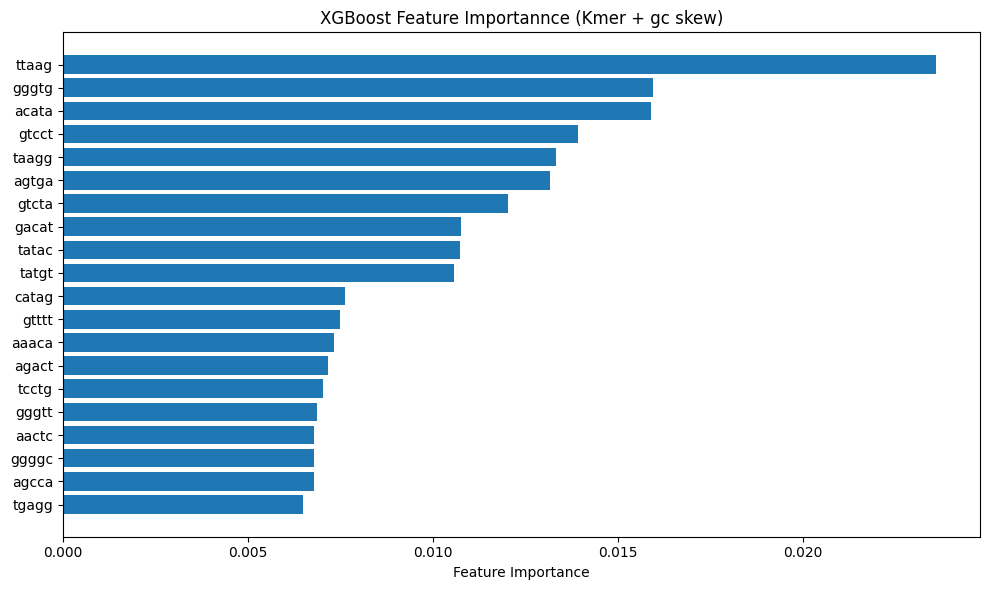

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split

# Prepare your data
# X = df.drop('target', axis=1)
# y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Train XGBoost model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train)

# Get feature importances
importances = xgb.feature_importances_
feature_names = X.columns

# Create a DataFrame for ranking
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Show top 10 features
print(importance_df.head(10))

# Plot top 20
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:20][::-1], importance_df['Importance'][:20][::-1])
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importannce (Kmer + gc skew)')
plt.tight_layout()
plt.show()

  Feature  Importance
0   tatac    0.006210
1   atagc    0.005844
2   ctgcg    0.005569
3   gtcct    0.005304
4   agact    0.004813
5   gacat    0.004812
6   aactc    0.004343
7   tgatc    0.004289
8   gggga    0.004285
9   gggtg    0.003982


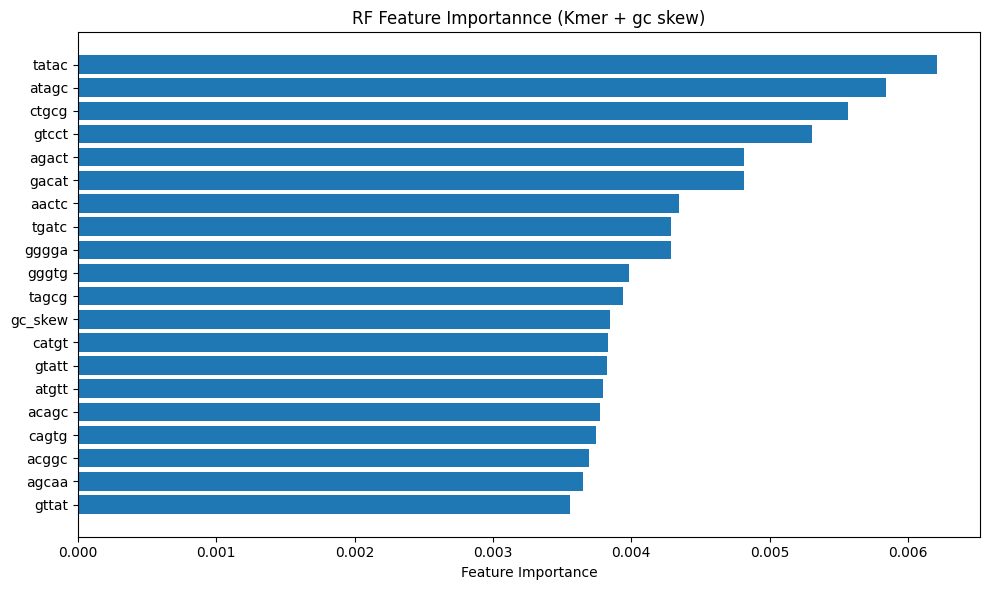

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split

# Prepare your data
# X = df.drop('target', axis=1)
# y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Train RF model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importances = rf.feature_importances_
feature_names = X.columns

# Create a DataFrame for ranking
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Show top 10 features
print(importance_df.head(10))

# Plot top 20
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:20][::-1], importance_df['Importance'][:20][::-1])
plt.xlabel('Feature Importance')
plt.title('RF Feature Importannce (Kmer + gc skew)')
plt.tight_layout()
plt.show()